In [ ]:
# Natural Language Toolkit

In [1]:
# Install and Import NLTK

In [5]:
!pip install nltk

In [8]:
# Download Comon datasets (run only conce)

In [1]:
import nltk

In [10]:
nltk.download('punkt')     # For tokenization

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\komal\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [11]:
nltk.download('stopwords')  # For stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\komal\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [12]:
nltk.download('wordnet')      # for lemmatization

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\komal\AppData\Roaming\nltk_data...


True

In [13]:
nltk.download('averaged_perceptron_tagger')        # for pos tagging

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\komal\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger.zip.


True

In [14]:
nltk.download('movie_reviews')     # for ml examples later

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\komal\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\movie_reviews.zip.


True

In [15]:
print("NLTK successfully installed and ready to use!")

NLTK successfully installed and ready to use!


In [20]:
# Step 2 : Tokenization

# Tokenization means breaking a sentence or paragraph into parts - words or sentence
from nltk.tokenize import word_tokenize, sent_tokenize

text = "Natural Language Processing with NLTK is Fun and educational. Let's learn it step by step!"

# Sentence Tokenization tokenization
sentences = sent_tokenize(text)
print("Sentence Tokenization:\n", sentences)

# word tokenization
words = word_tokenize(text)
print("\nEord Tokenization:\n", words)

Sentence Tokenization:
 ['Natural Language Processing with NLTK is Fun and educational.', "Let's learn it step by step!"]

Eord Tokenization:
 ['Natural', 'Language', 'Processing', 'with', 'NLTK', 'is', 'Fun', 'and', 'educational', '.', 'Let', "'s", 'learn', 'it', 'step', 'by', 'step', '!']


In [19]:
import nltk
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\komal\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [21]:
# Step 3: Stopwords Removal                // text clean the,is,am,and,in,on : stop words list gheto ,useless words kadhun takto

# Stopwords are common word like "is", "the", "and" which don't carry much meaning 
# Removing them hepls model focus on importat words

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
filtered_words = [w for w in words if w.lower() not in stop_words]

print("words after removing stopwords:\n", filtered_words)

words after removing stopwords:
 ['Natural', 'Language', 'Processing', 'NLTK', 'Fun', 'educational', '.', 'Let', "'s", 'learn', 'step', 'step', '!']


In [22]:
# Step 4: stemming 

# Stemming reduce  a words to int base or root form
# Exmpole : Running -> run. studies-> studi

from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
stemmed_words = [stemmer.stem(w) for w in filtered_words]

print("Stemmed words:\n", stemmed_words)

Stemmed words:
 ['natur', 'languag', 'process', 'nltk', 'fun', 'educ', '.', 'let', "'s", 'learn', 'step', 'step', '!']


In [24]:
# Step : 5 : Lemmatization

# Lemmatization is similar to stemming but more accurate and returns real words.
# It uses the wordNet dictinoary

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
lemmatized_words = [lemmatizer.lemmatize(w) for w in filtered_words]

print("Lemmatized words:\n", lemmatized_words)

Lemmatized words:
 ['Natural', 'Language', 'Processing', 'NLTK', 'Fun', 'educational', '.', 'Let', "'s", 'learn', 'step', 'step', '!']


In [25]:
import nltk 
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\komal\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


True

In [26]:
# Step 6: part of speech (POS) Tagging 

# POS tagging indentify whether a word is a noun , verb, adjective, stc
# This helps in understanding the grammatical structure of text 

pos_tags = nltk.pos_tag(filtered_words)
print("Pard of Speech Tagging:\n", pos_tags)

Pard of Speech Tagging:
 [('Natural', 'JJ'), ('Language', 'NNP'), ('Processing', 'NNP'), ('NLTK', 'NNP'), ('Fun', 'NNP'), ('educational', 'JJ'), ('.', '.'), ('Let', 'VB'), ("'s", 'POS'), ('learn', 'JJ'), ('step', 'NN'), ('step', 'NN'), ('!', '.')]


Words Frequency:

step: 2
Natural: 1
Language: 1
Processing: 1
NLTK: 1


<Axes: title={'center': 'Top 10 words Frequencies'}, xlabel='Samples', ylabel='Counts'>

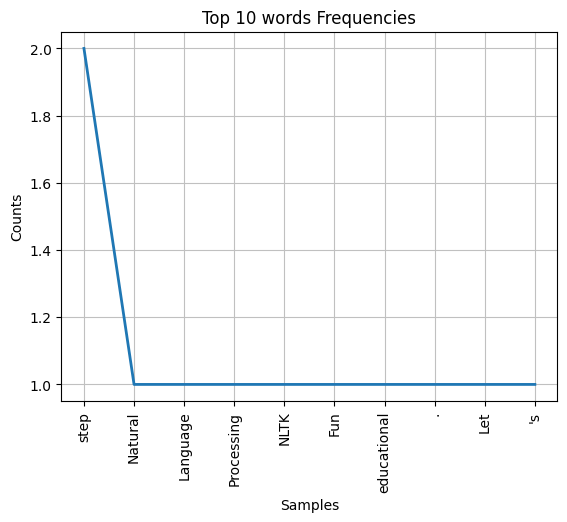

In [27]:
# step 7: Frequency Distibution

# Drequency Distribution helps count how many times each word appeares

from nltk import FreqDist

freq_dist = FreqDist(filtered_words)
print("Words Frequency:\n")
for word, freq in freq_dist.most_common(5):   # Show top 5
    print(f"{word}: {freq}")

# Plot words Frequency 
freq_dist.plot(10, title="Top 10 words Frequencies")

In [2]:
# Simple Text Classification Example 

# Let's Classify movie review (positive or nagative) using NLTK's dataset
# This shows how NLTK is connected to machine Learning 

import random
from nltk.corpus import movie_reviews

# Load dataset
documents = [(list(movie_reviews.words(fileid)), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

# Shuffle data for randomness
random.shuffle(documents)

# Extract all words and find frequency
all_words = nltk.FreqDist(w.lower() for w in movie_reviews.words())
word_features = list(all_words)[:2000] # top 2000 words as features

def find_features(document):
    words = set(document)
    features = {}
    for w in word_features:
        features[w] = (w in words)
    return features

# Prepare training data
featuresets = [(find_features(rev), category) for (rev, category) in documents]

# Split into train and test
train_set, test_set = featuresets[100:], featuresets[:100]

# Train a simple Naive Bayes Classifier
classifier = nltk.NaiveBayesClassifier.train(train_set)

# Test accuracy
accuracy = nltk.classify.accuracy(classifier, test_set) * 100
print(f"Classifier Accuracy: {accuracy:.2f}%")

# Show most informative features
classifier.show_most_informative_features(10)

Classifier Accuracy: 84.00%
Most Informative Features
             outstanding = True              pos : neg    =     10.9 : 1.0
                   mulan = True              pos : neg    =      9.1 : 1.0
                  seagal = True              neg : pos    =      7.7 : 1.0
             wonderfully = True              pos : neg    =      7.7 : 1.0
                   damon = True              pos : neg    =      6.4 : 1.0
                   flynt = True              pos : neg    =      5.7 : 1.0
                   awful = True              neg : pos    =      5.6 : 1.0
                  wasted = True              neg : pos    =      5.3 : 1.0
                    lame = True              neg : pos    =      5.1 : 1.0
                   waste = True              neg : pos    =      5.1 : 1.0
